# Árvores de decisão

Francisco Aparecido Rodrigues, francisco@icmc.usp.br.<br>
Universidade de São Paulo, São Carlos, Brasil.<br>
https://sites.icmc.usp.br/francisco <br>

## Exercícios para entregar

1 - Considere os dados abaixo. Ajuste um modelo de regressão usando: regressão polinomial, k-vizinhos e árvore de decisão.

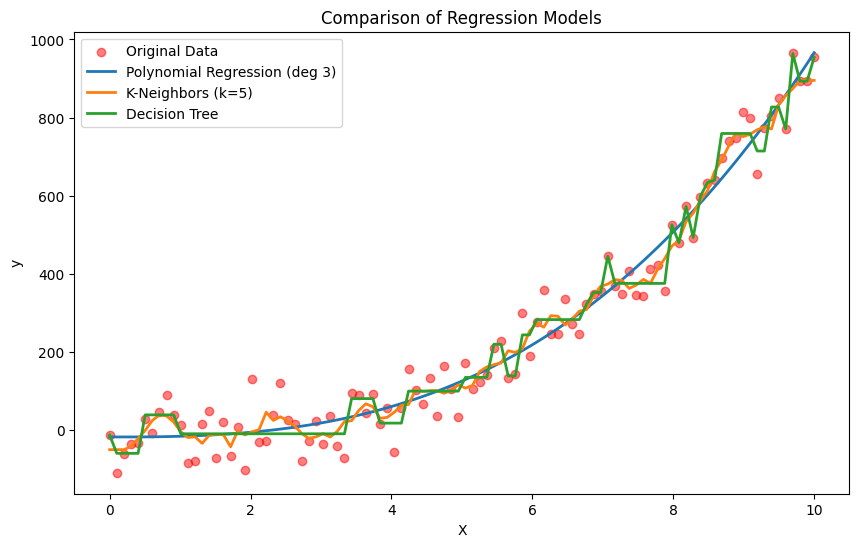

Polynomial Score: 0.9608
KNN Score: 0.9694
Decision Tree Score: 0.9798


In [34]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import make_pipeline

N = 100
X = np.linspace(0,10,N)
y = X**3 + np.random.normal(0,50, N)

# Reshape X to a 2D array
X = X.reshape(-1,1)

# Regressao polinomial
poly_model = make_pipeline(PolynomialFeatures(degree=3), LinearRegression())
poly_model.fit(X, y)
y_poly = poly_model.predict(X)

# K-Neighbors
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(X, y)
y_knn = knn_model.predict(X)

# Arvore de decisão
tree_model = DecisionTreeRegressor(max_depth=5)
tree_model.fit(X, y)
y_tree = tree_model.predict(X)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', alpha=0.5, label='Original Data')
plt.plot(X, y_poly, label='Polynomial Regression (deg 3)', linewidth=2)
plt.plot(X, y_knn, label='K-Neighbors (k=5)', linewidth=2)
plt.plot(X, y_tree, label='Decision Tree', linewidth=2)

plt.title('Comparison of Regression Models')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()

print(f"Polynomial Score: {poly_model.score(X, y):.4f}")
print(f"KNN Score: {knn_model.score(X, y):.4f}")
print(f"Decision Tree Score: {tree_model.score(X, y):.4f}")

2 - Faça a classificação da base vertebralcolumn-3C.

Accuracy for Vertebral Column: 0.8548


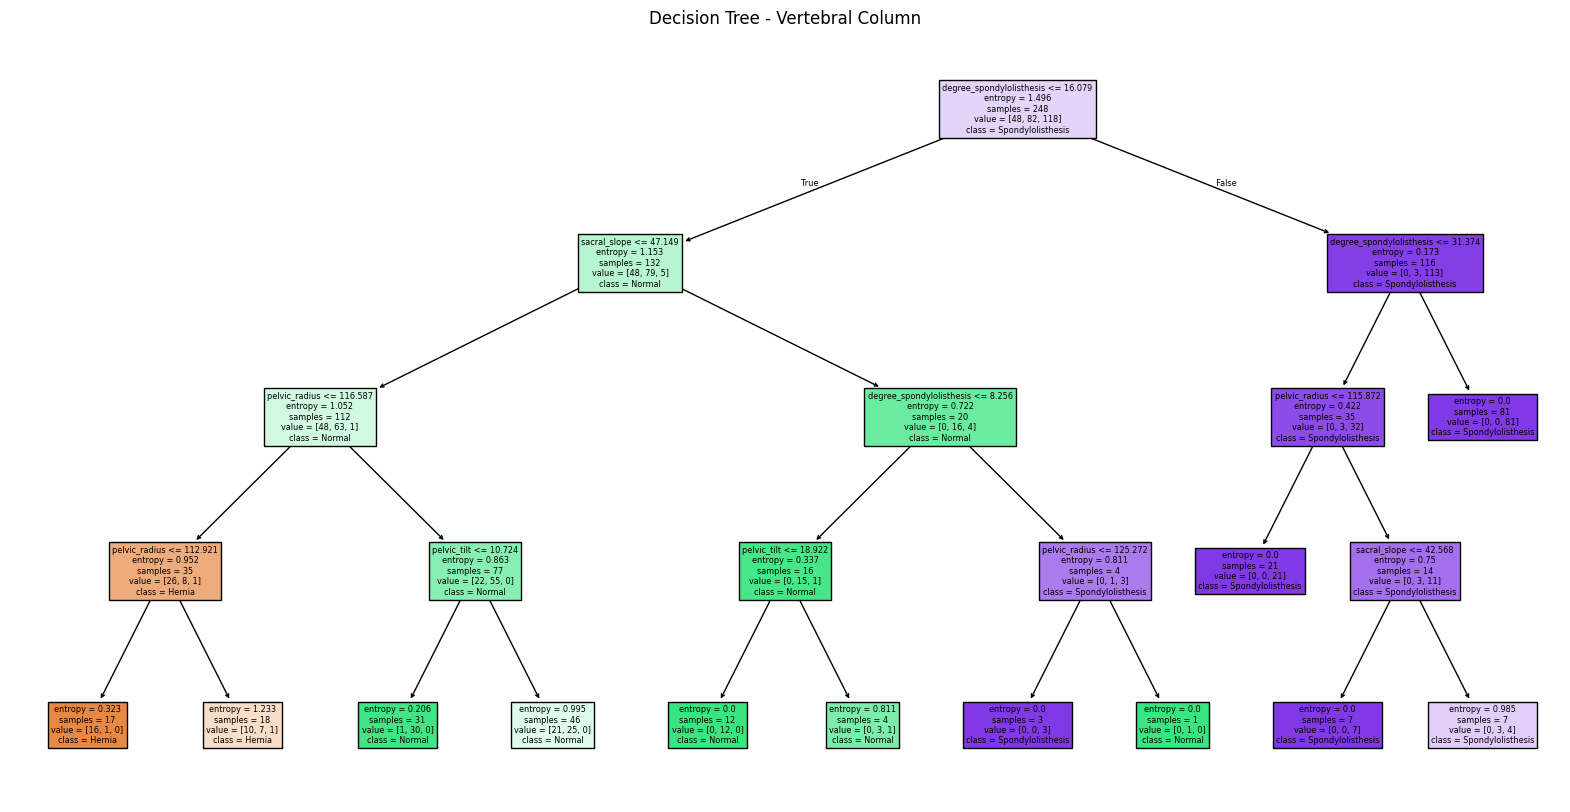

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

df = pd.read_csv("/content/drive/MyDrive/Data/vertebralcolumn-3C.csv")

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy for Vertebral Column: {accuracy:.4f}")

plt.figure(figsize=(20,10))
plot_tree(model, feature_names=df.columns[:-1], class_names=np.unique(y).astype(str), filled=True)
plt.title("Decision Tree - Vertebral Column")
plt.show()

3 - Ajuste um modelo de regressão aos dados de concreto para predizer a variável
concrete_compressive_strength.

Linear Regression R2 Score: 0.6276
Polynomial Regression (Degree 2) R2 Score: 0.7843


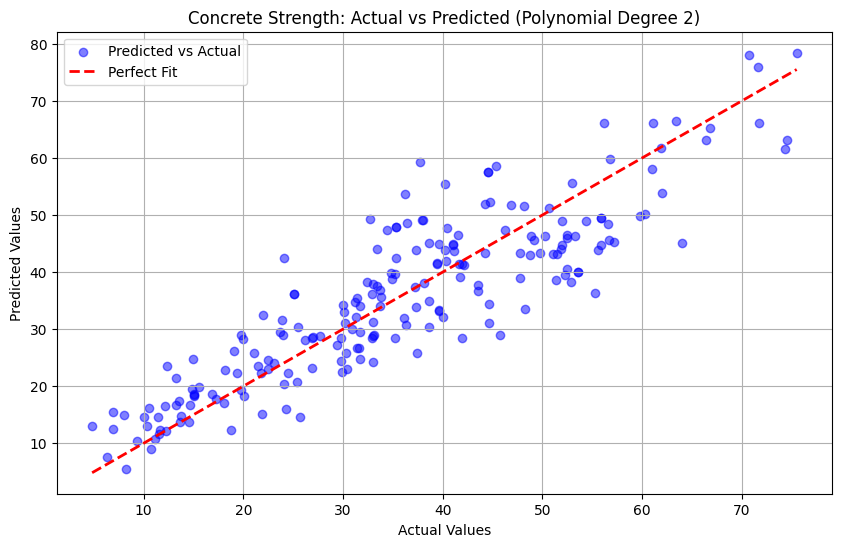

In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import r2_score

# Load dataset
df = pd.read_csv("/content/drive/MyDrive/Data/concrete_data.csv")

# Split features and target
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 1. Simple Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# 2. Polynomial Regression (Degree 2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)

print(f"Linear Regression R2 Score: {r2_score(y_test, y_pred_lr):.4f}")
print(f"Polynomial Regression (Degree 2) R2 Score: {r2_score(y_test, y_pred_poly):.4f}")

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_poly, color='blue', alpha=0.5, label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Fit')

plt.title('Concrete Strength: Actual vs Predicted (Polynomial Degree 2)')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.legend()
plt.grid(True)
plt.show()

4 - Escolha uma base de dados e compare a influencia da medida de impureza na classificação (Gini, Entropia, etc).

Accuracy with Gini: 0.3350
Accuracy with Entropy: 0.3354


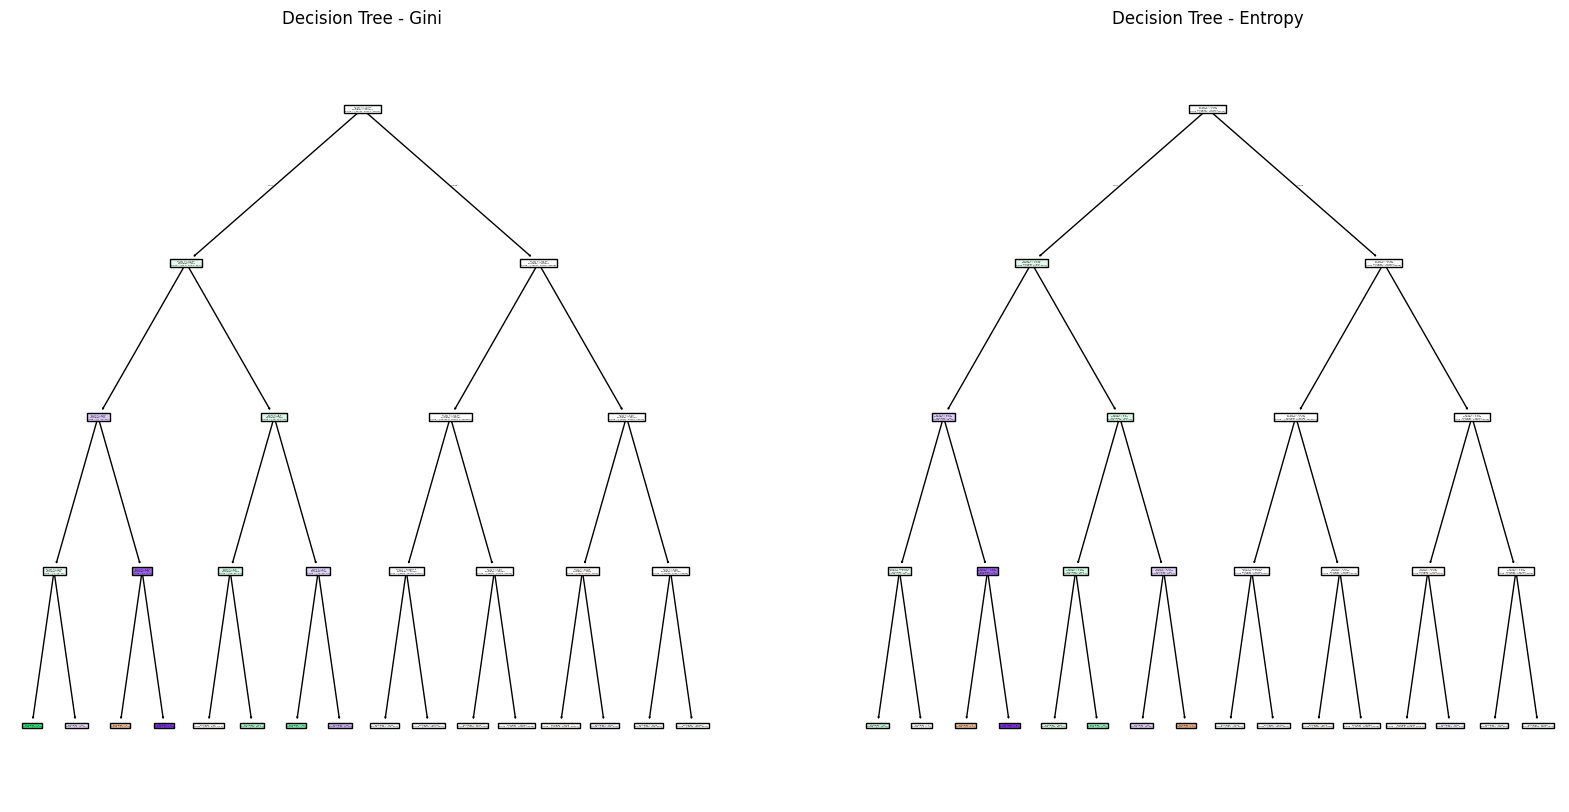

In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score


df = pd.read_csv("/content/drive/MyDrive/Data/student_mental_health_burnout.csv").drop(columns = [
"gender",
"course",
"year",
"stress_level",
"sleep_quality",
"internet_quality"
])

X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model_gini = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)
model_gini.fit(X_train, y_train)
y_pred_gini = model_gini.predict(X_test)
acc_gini = accuracy_score(y_test, y_pred_gini)

# Entropy
model_entropy = DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)
model_entropy.fit(X_train, y_train)
y_pred_entropy = model_entropy.predict(X_test)
acc_entropy = accuracy_score(y_test, y_pred_entropy)

print(f"Accuracy with Gini: {acc_gini:.4f}")
print(f"Accuracy with Entropy: {acc_entropy:.4f}")

# Plotting comparison
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

plot_tree(model_gini, filled=True, ax=ax[0])
ax[0].set_title("Decision Tree - Gini")

plot_tree(model_entropy, filled=True, ax=ax[1])
ax[1].set_title("Decision Tree - Entropy")

plt.show()

5 - Considere um conjunto de dados com n observações (Vehicle).
* Gere uma nova amostra de treinamento selecionando n observações de forma aleatória com reposição a
partir do conjunto de dados original. Esse procedimento é conhecido como reamostragem bootstrap.
*  Utilize essa nova amostra para treinar uma árvore de decisão.
* Repita esse processo B vezes, gerando B árvores diferentes.
* Para classificar uma nova observação x, utilize todas as árvores geradas e registre a classe prevista por
cada uma delas.
* A classificação final de x deve ser obtida pela moda das previsões das B árvores, isto é, pela classe mais
frequentemente prevista.
* Faça um gráfico de B versus a acurácia. Esse processo melhora a classificação?

Obtenha um gráfico como esse:
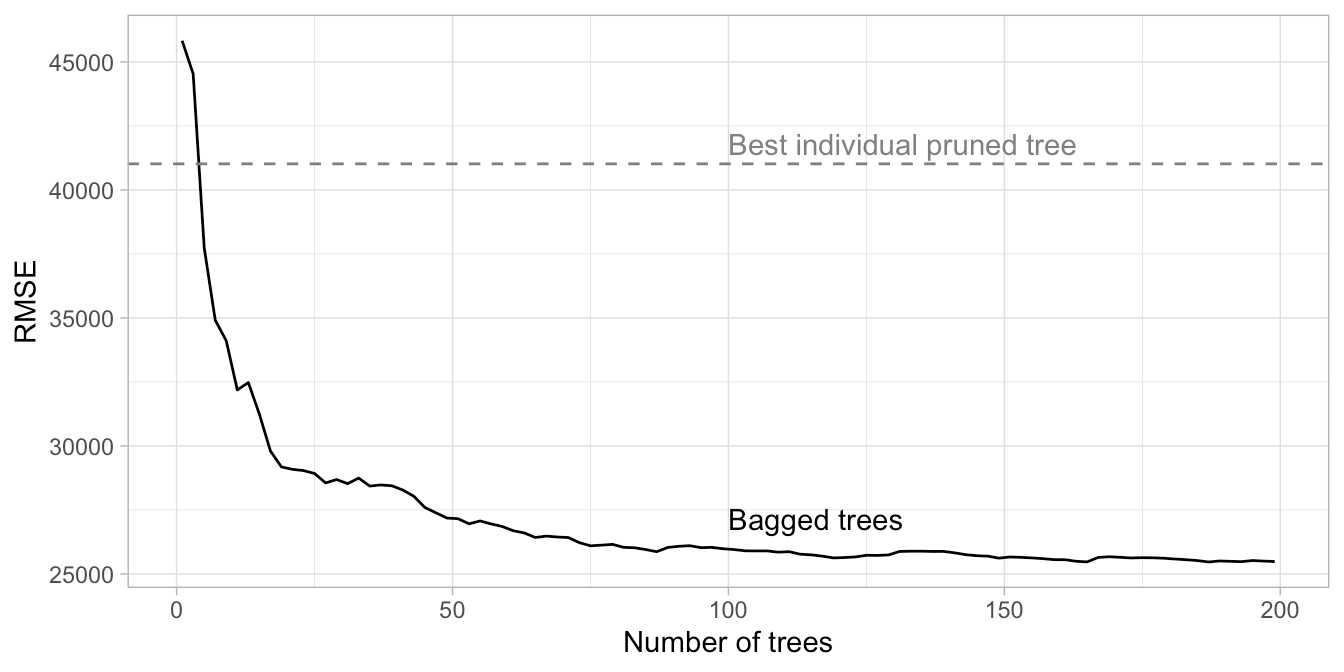

In [136]:
df.iloc[845]

,845
Comp,85
Circ,36
D.Circ,66
Rad.Ra,123
Pr.Axis.Ra,55
Max.L.Ra,5
Scat.Ra,120
Elong,56
Pr.Axis.Rect,17
Max.L.Rect,128


Treinando as árvores de regressão...


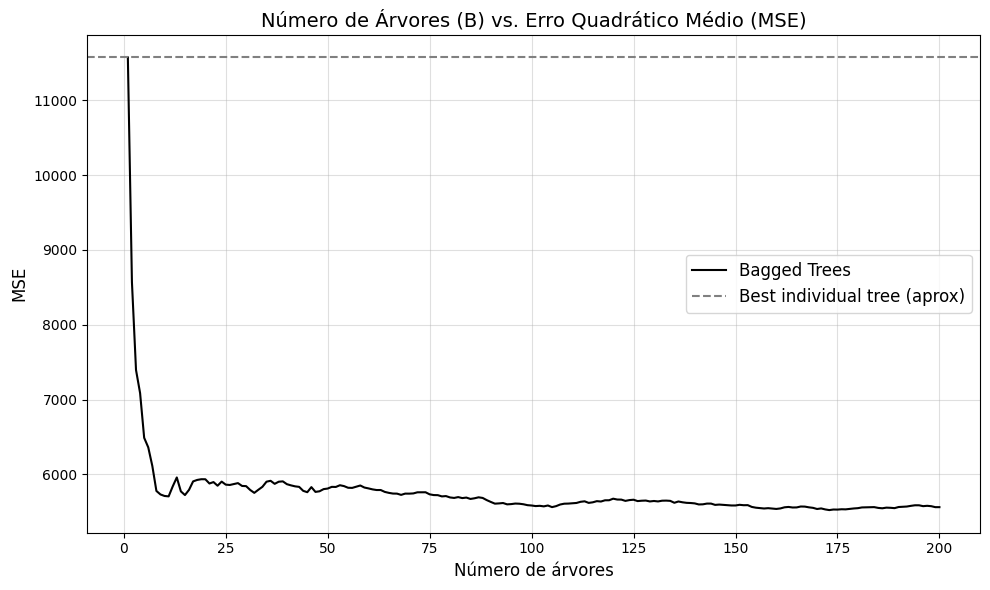

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=500, n_features=10, noise=0.5, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

n = len(X_train)
B = 200

arvores = []
previsoes_todas_arvores = []

print("Treinando as árvores de regressão...")

for j in range(B):
    indices_bootstrap = np.random.choice(n, size=n, replace=True)
    X_boot = X_train[indices_bootstrap]
    y_boot = y_train[indices_bootstrap]

    modelo = DecisionTreeRegressor(max_depth=5, random_state=None)
    modelo.fit(X_boot, y_boot)
    arvores.append(modelo)

    previsoes_todas_arvores.append(modelo.predict(X_test))

previsoes_todas_arvores = np.array(previsoes_todas_arvores)

mse_B = []

for b in range(1, B + 1):
    previsoes_b_arvores = previsoes_todas_arvores[:b, :]
    media_b = np.mean(previsoes_b_arvores, axis=0)
    erro = mean_squared_error(y_test, media_b)
    mse_B.append(erro)

plt.figure(figsize=(10, 6))
plt.plot(range(1, B + 1), mse_B, color='black', label='Bagged Trees')
plt.axhline(y=mse_B[0], color='gray', linestyle='--', label='Best individual tree (aprox)')

plt.title('Número de Árvores (B) vs. Erro Quadrático Médio (MSE)', fontsize=14)
plt.xlabel('Número de árvores', fontsize=12)
plt.ylabel('MSE', fontsize=12)
plt.legend(loc='center right', fontsize=12)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()